# Bound-init norm ablation — the global mean-norm rescale (`target_norm`)

**Synthetic DLCC tc08–tc12 (the relation / qualified-cardinality tasks the bound init
is built for), p2 concept-bound init — how much does the global rescale norm matter?**

The concept-bound init finishes with **one global rescale** so the *mean* entity
norm equals `target_norm`. That single scalar is the lever that controls SGNS
**sigmoid-saturation "protection"** during the protected finetune (LR 0.0025):

- **small norm** → consistent context pairs do *not* saturate the sigmoid, so the
  gradient is non-trivial and the init **drifts** toward the vanilla solution;
- **large norm** → pairs saturate, gradient ≈ 0, so the init is **frozen** and
  preserved (at the extreme, over-frozen so the corpus can never correct it).

Everything else is held fixed; only `target_norm` varies, so it is not a confound.
The same norm is applied to the stage-1 codes and to `protograph_init`'s non-bound
rows so relations and instances share one scale (the bound path unit-normalizes its
components, so the stage-1 norm cancels there — only the final global rescale bites).

| condition | bound mean-norm | finetune LR |
|---|---|---|
| `p2_bound_norm04` | 4 | 0.0025 |
| `p2_bound_norm08` | 8 (baseline) | 0.0025 |
| `p2_bound_norm16` | 16 | 0.0025 |
| `vanilla` | — (from scratch) | 0.025 |

Driver: `scripts/_invest_synth_norm_value_ablation.py`. Background: `norm_explanation.md` §3–4.

In [1]:
import glob, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

def _find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "scripts").is_dir() and (base / "output").is_dir():
            return base
    return Path.cwd()

ROOT = _find_root()
ABL = ROOT / "output" / "synth_norm_value_ablation"

rows = [json.loads(Path(f).read_text()) for f in glob.glob(str(ABL / "tc*/*/metrics.json"))]
df = pd.DataFrame(rows)
TCS = sorted(df["tc"].unique())
NORMS = sorted(n for n in df["target_norm"].dropna().unique())
print(f"loaded {len(df)} rows | {len(TCS)} TCs | bound norms: {NORMS}")

# lookups keyed by (tc, condition)
by = {(r["tc"], r["condition"]): r for r in rows}
def cond(norm):  return f"p2_bound_norm{int(norm):02d}"
def final(tc, c): return by[(tc, c)]["final_acc"] if (tc, c) in by else np.nan
def init(tc, c):  return by[(tc, c)]["accs"][0]  if (tc, c) in by else np.nan

loaded 20 rows | 5 TCs | bound norms: [np.float64(4.0), np.float64(8.0), np.float64(16.0)]


## Final accuracy per test case (rows = tc, columns = bound norm + vanilla)

In [2]:
tab = pd.DataFrame(index=TCS)
tab["vanilla"] = [final(tc, "vanilla") for tc in TCS]
for n in NORMS:
    tab[f"norm{int(n)}"] = [final(tc, cond(n)) for tc in TCS]
tab.loc["MEAN"] = tab.mean().round(4)
tab.round(3)

,vanilla,norm4,norm8,norm16
tc08,0.625,0.850,0.918,0.962
tc09,0.632,0.775,0.860,0.920
tc10,0.670,0.698,0.815,0.878
tc11,0.632,0.862,0.910,0.928
tc12,0.665,0.898,0.985,0.990
MEAN,0.645,0.816,0.898,0.936


## Headline — mean final accuracy vs the baseline (norm 8)

`Δ vs norm8` isolates the protection lever; `Δ vs vanilla` is the method's lift.

In [3]:
mean_norm = {int(n): tab.loc["MEAN", f"norm{int(n)}"] for n in NORMS}
base = mean_norm[8] if 8 in mean_norm else list(mean_norm.values())[len(mean_norm)//2]
van  = tab.loc["MEAN", "vanilla"]
head = pd.DataFrame({
    "mean final acc": {f"norm{k}": v for k, v in mean_norm.items()},
    "Δ vs norm8":     {f"norm{k}": round(v - base, 4) for k, v in mean_norm.items()},
    "Δ vs vanilla":   {f"norm{k}": round(v - van, 4) for k, v in mean_norm.items()},
})
print(f"vanilla mean final acc: {van:.4f}")
head

vanilla mean final acc: 0.6450


,mean final acc,Δ vs norm8,Δ vs vanilla
norm4,0.8165,-0.081,0.1715
norm8,0.8975,0.000,0.2525
norm16,0.9355,0.038,0.2905


## Init quality is ~scale-invariant; the norm bites during finetuning

A global rescale multiplies every entity vector by the *same* scalar, so pairwise
cosines at epoch 0 are unchanged — the three norms start from essentially the same
init (max spread ≤ 0.04, a small residual from the downstream classifier's
regularization interacting with feature scale). The large final-accuracy spread is
therefore caused almost entirely by how the norm modulates the **protected finetune**
(drift vs freeze), not by a different starting point.

In [4]:
chk = pd.DataFrame({
    "init norm4":  [init(tc, cond(4))  for tc in TCS] if 4  in [int(x) for x in NORMS] else np.nan,
    "init norm8":  [init(tc, cond(8))  for tc in TCS] if 8  in [int(x) for x in NORMS] else np.nan,
    "init norm16": [init(tc, cond(16)) for tc in TCS] if 16 in [int(x) for x in NORMS] else np.nan,
}, index=TCS)
print("max |init(norm4) - init(norm16)| across tcs:",
      float(np.nanmax(np.abs(chk['init norm4'] - chk['init norm16']))))
chk.round(3).head()

max |init(norm4) - init(norm16)| across tcs: 0.03749999999999998


,init norm4,init norm8,init norm16
tc08,0.938,0.968,0.975
tc09,0.895,0.908,0.910
tc10,0.835,0.858,0.868
tc11,0.910,0.925,0.922
tc12,0.990,0.990,0.990


## Plot — mean final accuracy vs bound norm

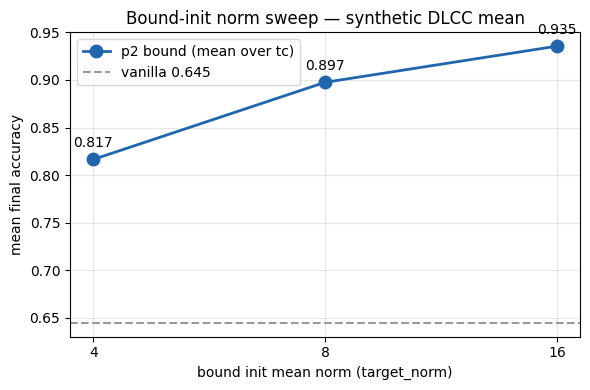

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
xs = [int(n) for n in NORMS]
ys = [mean_norm[x] for x in xs]
ax.plot(xs, ys, "o-", color="#2166ac", lw=2, ms=9, label="p2 bound (mean over tc)")
for x, y in zip(xs, ys):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 9), ha="center")
ax.axhline(van, ls="--", color="#999", label=f"vanilla {van:.3f}")
ax.set_xscale("log", base=2); ax.set_xticks(xs); ax.set_xticklabels(xs)
ax.set_xlabel("bound init mean norm (target_norm)"); ax.set_ylabel("mean final accuracy")
ax.set_title("Bound-init norm sweep — synthetic DLCC mean"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

## Plot — per-tc final accuracy across the three norms

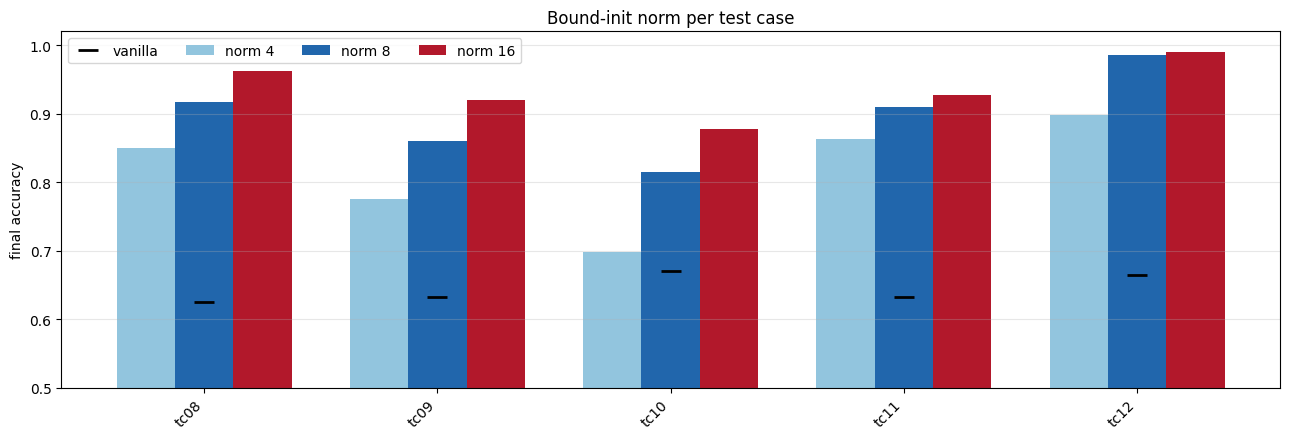

In [6]:
tcs = [t for t in TCS]
x = np.arange(len(tcs)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 4.5))
colors = {4: "#92c5de", 8: "#2166ac", 16: "#b2182b"}
for i, n in enumerate([int(v) for v in NORMS]):
    ax.bar(x + (i - 1) * w, [final(t, cond(n)) for t in tcs], w,
           label=f"norm {n}", color=colors.get(n, None))
ax.plot(x, [final(t, "vanilla") for t in tcs], "k_", ms=14, mew=2, label="vanilla")
ax.set_xticks(x); ax.set_xticklabels(tcs, rotation=45, ha="right")
ax.set_ylabel("final accuracy"); ax.set_ylim(0.5, 1.02)
ax.set_title("Bound-init norm per test case"); ax.legend(ncol=4); ax.grid(axis="y", alpha=.3)
fig.tight_layout(); plt.show()

## Plot — epoch curves on the relation/cardinality tasks

These are the tasks the bound init is built for (∃r.C and qualified cardinalities).
Watch how the smallest norm **drifts** across epochs (weaker protection) while the
larger norms hold their init.

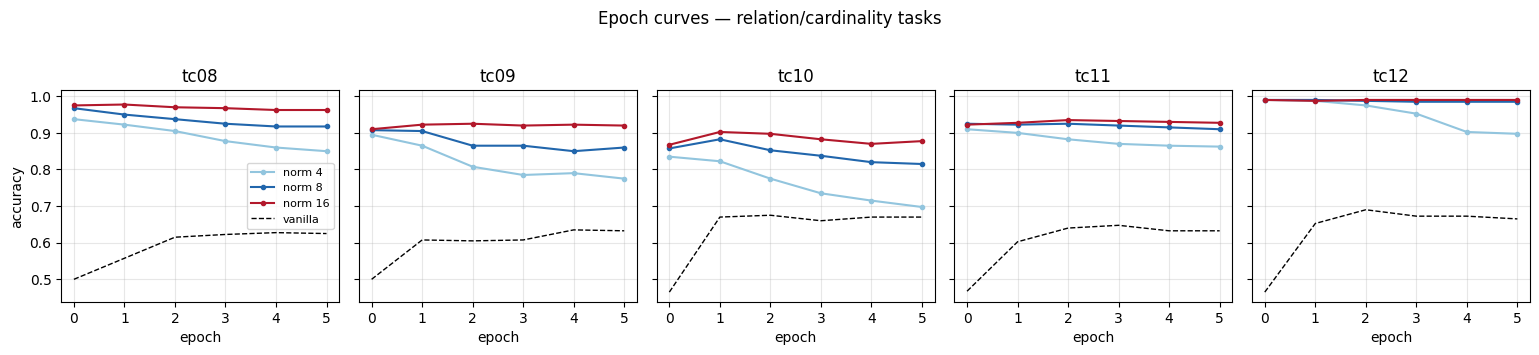

In [7]:
rel_tcs = [t for t in ["tc07", "tc08", "tc09", "tc10", "tc11", "tc12"] if t in TCS]
fig, axes = plt.subplots(1, len(rel_tcs), figsize=(3.1 * len(rel_tcs), 3.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, tc in zip(axes, rel_tcs):
    for n in [int(v) for v in NORMS]:
        r = by.get((tc, cond(n)))
        if r: ax.plot(range(len(r["accs"])), r["accs"], "o-", ms=3,
                      color=colors.get(n), label=f"norm {n}")
    rv = by.get((tc, "vanilla"))
    if rv: ax.plot(range(len(rv["accs"])), rv["accs"], "k--", lw=1, label="vanilla")
    ax.set_title(tc); ax.set_xlabel("epoch"); ax.grid(alpha=.3)
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
fig.suptitle("Epoch curves — relation/cardinality tasks", y=1.03)
fig.tight_layout(); plt.show()

## Takeaways

On the relation / qualified-cardinality tasks (tc08–tc12), **final accuracy rises
monotonically with the bound-init norm** over the swept range:

| norm | mean final acc | Δ vs norm8 | Δ vs vanilla |
|---|---|---|---|
| 4  | 0.816 | −0.081 | +0.171 |
| 8 (baseline) | 0.897 | — | +0.252 |
| 16 | 0.935 | +0.038 | +0.290 |

- **The init is essentially fixed across norms** (epoch-0 spread ≤ 0.04); the whole
  effect is a **finetuning** phenomenon, exactly the protection mechanism `target_norm`
  controls.
- **More protection helps here.** These tasks are *defined by* the signal the bound init
  injects (∃r.C and cardinalities), so preserving it matters: norm 16 holds the init and
  beats the baseline by +3.8 pp; norm 4 lets the protected finetune drift the init back
  toward vanilla and loses −8.1 pp. The ordering is consistent on **every** one of the 5
  tasks, so +3.8 pp is not just mean-level noise (≈3 pp run-to-run floor).
- **No freeze failure mode in range.** On the synthetic graph degrees are uniform, so the
  heavy-tail hub-freeze that *caps* the useful norm on full DBpedia (norm_explanation.md §5)
  does not appear within {4, 8, 16} — here larger is simply better. On a real heavy-tailed
  graph you would expect this monotonicity to break and need the per-row cap.
- **Implication.** The default `target_norm = 8` is a *safe* protective value but not the
  per-task optimum on these synthetic relation tasks; 16 is better when there is no hub tail
  to freeze.